In [53]:
%load_ext autoreload
%autoreload 2
from wc import simulate_wc_w_dist, find_fixed_points, merge_fixed_points
import jax.numpy as jnp
import jax
import seaborn as sns
key = jax.random.PRNGKey(0)
plane_size = 80.0
num_E, num_I = 40, 10
N = num_E + num_I

key_pos, key_w, key = jax.random.split(key, 3)
pos_init = jax.random.uniform(key_pos, (N, 2), minval=0, maxval=plane_size)   # only build this once

init_neurons = jnp.concatenate([0.35 * jnp.ones(num_E), 0.15 * jnp.ones(num_I)])
is_exc = jnp.concatenate([jnp.ones(num_E, dtype=bool), jnp.zeros(num_I, dtype=bool)])

w_EE, w_EI, w_IE, w_II = 1.6, 2.8, 1.6, 2.8  
exc_target = is_exc[:, None]
exc_source = is_exc[None, :]

magnitude = jnp.where(exc_source,
                       jnp.where(exc_target, w_EE, w_IE),
                       jnp.where(exc_target, w_EI, w_II))
sign = jnp.where(exc_source, 1.0, -1.0)

jitter = 1.0 + 0.2 * jax.random.normal(key_w, (N, N))   # +/-20%ish per-connection variation
base_weight_matrix = magnitude * sign * jitter

I_ext = jnp.ones(N)
dt = 0.5
range_t = jnp.arange(0, 100, dt)
a_dist = 1 / (0.3 * plane_size)
a_sigmoid = 1.2
theta = 3.5
tau_E = 1.0
tau_I = 0.5

r_trace = simulate_wc_w_dist(
    init_state=init_neurons, pos_init=pos_init, is_exc=is_exc, I_ext=I_ext,
    range_t=range_t, a_dist=a_dist, a_sigmoid=a_sigmoid, W=base_weight_matrix,
    dt=dt, tau_I=tau_I, tau_E=tau_E, theta=theta,
)

rE_trace = r_trace[:, :num_E]
rI_trace = r_trace[:, num_E:]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<Axes: >

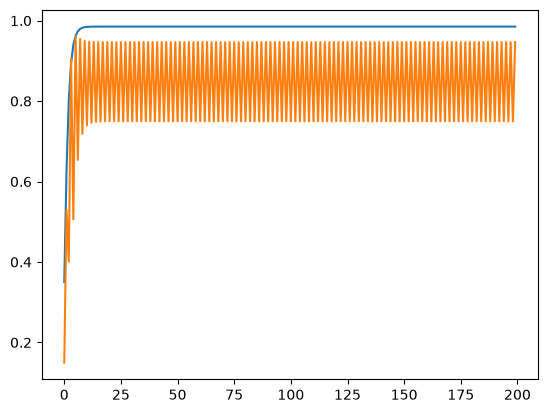

In [28]:
sns.lineplot(rE_trace[:,3])
sns.lineplot(rI_trace[:,9])

Parameters I plan to vary:
1. W_IE, W_EI, WEE, W_EI, Iext


In [ ]:
params = {
    "exc_map": is_exc,
    "2dmap": pos_init,
    "ext_input": I_ext,
    "distance_decay": a_dist,
    "sigmoid_steepness": a_sigmoid,
    "theta": theta,
    "weights": base_weight_matrix,
    "tau_I": tau_I,
    "tau_E": tau_E,
}
fixed_points = find_fixed_points(params, steps=25, num_samples=30)



In [ ]:
from wc import jacobian_at

all_fixed_points_clean = merge_fixed_points(fixed_points)
for i in range(len(all_fixed_points_clean)):
    J = jacobian_at(all_fixed_points_clean[i], params)
    eigenvals, eigenvecs = jnp.linalg.eig(J)
    print("eigenvals: ", eigenvals)


eigenvals:  [-2.7369225 +0.0000000e+00j -0.9238924 +0.0000000e+00j
 -0.9689462 +0.0000000e+00j -2.045583  +0.0000000e+00j
 -1.961093  +0.0000000e+00j -2.023942  +0.0000000e+00j
 -2.0209353 +0.0000000e+00j -2.0104654 +0.0000000e+00j
 -2.0060465 +0.0000000e+00j -2.0029328 +0.0000000e+00j
 -2.000015  +0.0000000e+00j -1.9999999 +0.0000000e+00j
 -0.9980853 +7.9254457e-04j -0.9980853 -7.9254457e-04j
 -0.99802214+0.0000000e+00j -0.99867207+0.0000000e+00j
 -0.9995253 +0.0000000e+00j -0.9995875 +0.0000000e+00j
 -0.9996428 +0.0000000e+00j -0.99975944+0.0000000e+00j
 -0.9998121 +6.4244459e-06j -0.9998121 -6.4244459e-06j
 -0.99993086+0.0000000e+00j -0.9998888 +0.0000000e+00j
 -0.9998709 +0.0000000e+00j -0.9999646 +0.0000000e+00j
 -1.000016  +0.0000000e+00j -0.9999843 +0.0000000e+00j
 -0.99998736+0.0000000e+00j -0.999996  +4.8077686e-06j
 -0.999996  -4.8077686e-06j -0.99999386+0.0000000e+00j
 -1.0000019 +0.0000000e+00j -1.0000012 +0.0000000e+00j
 -0.9999997 +0.0000000e+00j -0.99999934+0.0000000e+00

In [38]:
def get_local_behavior(params):
    fixed_points = find_fixed_points(params, steps=25, num_samples=30)
    all_fixed_points_clean = merge_fixed_points(fixed_points)
    max_real_parts = []
    max_complex_coeff = []
    for i in range(len(all_fixed_points_clean)):
        J = jacobian_at(all_fixed_points_clean[i], params)
        eigenvals, eigenvectors = jnp.linalg.eig(J)
        max_real_parts.append(jnp.max(eigenvals.real))
        max_complex_coeff.append(jnp.max(jnp.abs(eigenvals.imag)))
    return jnp.max(jnp.array(max_real_parts)), jnp.max(jnp.array(max_complex_coeff))




In [45]:
#sweep ranges
wI_range = jnp.linspace(0.8, 13, 15)     
wE_range = jnp.linspace(0.5, 5, 10)     
extI_range = jnp.linspace(0, 6, 5)    
extE_range = jnp.linspace(0, 6, 5)
wI_sweep_tracker = []
i = 0
for wI in wI_range:
    print(f"starting {i}")
    exc_target = is_exc[:, None]
    exc_source = is_exc[None, :]

    magnitude = jnp.where(exc_source,
                        jnp.where(exc_target, w_EE, w_IE),
                        jnp.where(exc_target, wI, wI))
    sign = jnp.where(exc_source, 1.0, -1.0)
    weight_matrix = magnitude * sign * jitter

    params = {
        "exc_map": is_exc,
        "2dmap": pos_init,
        "ext_input": I_ext,
        "distance_decay": a_dist,
        "sigmoid_steepness": a_sigmoid,
        "theta": theta,
        "weights": weight_matrix,
        "tau_I": tau_I,
        "tau_E": tau_E,
    }
    
    wI_sweep_tracker.append(get_local_behavior(params))
    i+=1




starting 0
starting 1
starting 2
starting 3
starting 4
starting 5
starting 6
starting 7
starting 8
starting 9
starting 10
starting 11
starting 12
starting 13
starting 14


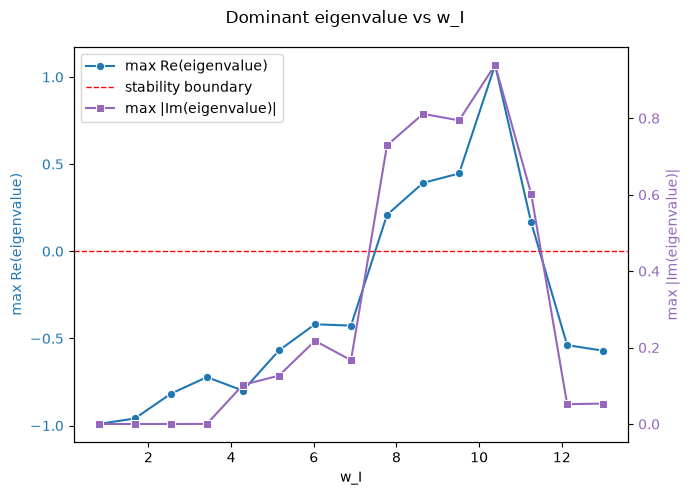

In [47]:
import matplotlib.pyplot as plt

max_real_parts, max_complex_coeffs = zip(*wI_sweep_tracker)
max_real_parts = jnp.array(max_real_parts)
max_complex_coeffs = jnp.array(max_complex_coeffs)

fig, ax1 = plt.subplots(figsize=(7, 5))

sns.lineplot(x=wI_range, y=max_real_parts, marker='o', color='tab:blue', ax=ax1, label='max Re(eigenvalue)')
ax1.axhline(0, color='red', linestyle='--', linewidth=1, label='stability boundary')
ax1.set_xlabel('w_I')
ax1.set_ylabel('max Re(eigenvalue)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
sns.lineplot(x=wI_range, y=max_complex_coeffs, marker='s', color='tab:purple', ax=ax2, label='max |Im(eigenvalue)|')
ax2.set_ylabel('max |Im(eigenvalue)|', color='tab:purple')
ax2.tick_params(axis='y', labelcolor='tab:purple')
ax2.grid(False)   # avoid double gridlines from the two overlapping axes

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
ax2.get_legend().remove()   # merged into ax1's legend above, so drop the duplicate

fig.suptitle('Dominant eigenvalue vs w_I')
fig.tight_layout()
plt.show()

In [55]:
wE_sweep_tracker = []
i = 0

for wE in wE_range:
    print(f"starting {i}")
    exc_target = is_exc[:, None]
    exc_source = is_exc[None, :]

    magnitude = jnp.where(exc_source,
                        jnp.where(exc_target, wE, wE),
                        jnp.where(exc_target, w_EI, w_II))
    sign = jnp.where(exc_source, 1.0, -1.0)
    weight_matrix = magnitude * sign * jitter

    params = {
        "exc_map": is_exc,
        "2dmap": pos_init,
        "ext_input": I_ext,
        "distance_decay": a_dist,
        "sigmoid_steepness": a_sigmoid,
        "theta": theta,
        "weights": weight_matrix,
        "tau_I": tau_I,
        "tau_E": tau_E,
    }
    
    wE_sweep_tracker.append(get_local_behavior(params))
    i+=1



starting 0
starting 1
starting 2
starting 3
starting 4
starting 5
starting 6
starting 7
starting 8
starting 9


[(Array(-0.7749936, dtype=float32), Array(0.00937313, dtype=float32)), (Array(0.36662698, dtype=float32), Array(0.09487119, dtype=float32)), (Array(-0.7013768, dtype=float32), Array(3.0124945e-06, dtype=float32)), (Array(-0.9683733, dtype=float32), Array(9.316165e-06, dtype=float32)), (Array(-0.9983599, dtype=float32), Array(0., dtype=float32)), (Array(-0.99991524, dtype=float32), Array(0., dtype=float32)), (Array(-0.9999954, dtype=float32), Array(0., dtype=float32)), (Array(-0.9999993, dtype=float32), Array(0., dtype=float32)), (Array(-0.9999995, dtype=float32), Array(0., dtype=float32)), (Array(-0.9999997, dtype=float32), Array(5.3888383e-09, dtype=float32))]


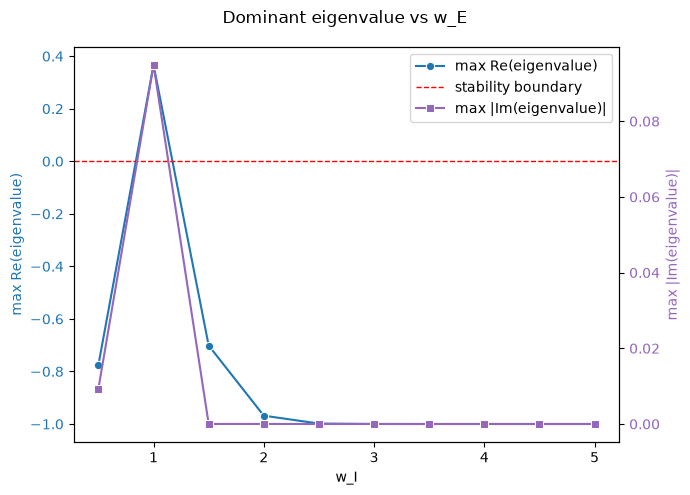

In [56]:

print(wE_sweep_tracker)

max_real_parts, max_complex_coeffs = zip(*wE_sweep_tracker)
max_real_parts = jnp.array(max_real_parts)
max_complex_coeffs = jnp.array(max_complex_coeffs)

fig, ax1 = plt.subplots(figsize=(7, 5))

sns.lineplot(x=wE_range, y=max_real_parts, marker='o', color='tab:blue', ax=ax1, label='max Re(eigenvalue)')
ax1.axhline(0, color='red', linestyle='--', linewidth=1, label='stability boundary')
ax1.set_xlabel('w_I')
ax1.set_ylabel('max Re(eigenvalue)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
sns.lineplot(x=wE_range, y=max_complex_coeffs, marker='s', color='tab:purple', ax=ax2, label='max |Im(eigenvalue)|')
ax2.set_ylabel('max |Im(eigenvalue)|', color='tab:purple')
ax2.tick_params(axis='y', labelcolor='tab:purple')
ax2.grid(False)   # avoid double gridlines from the two overlapping axes

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
ax2.get_legend().remove()   # merged into ax1's legend above, so drop the duplicate

fig.suptitle('Dominant eigenvalue vs w_E')
fig.tight_layout()
plt.show()

In [57]:
wExt_sweep_tracker = []
i = 0
# extI_range = jnp.linspace(0, 6, 5)    
# extE_range = jnp.linspace(0, 6, 5)

for extI in extI_range:
    for extE in extE_range:
        print(f"starting {i}")
        
        I_ext = jnp.concatenate([extE * jnp.ones(num_E), extI * jnp.ones(num_I)])

        params = {
            "exc_map": is_exc,
            "2dmap": pos_init,
            "ext_input": I_ext,
            "distance_decay": a_dist,
            "sigmoid_steepness": a_sigmoid,
            "theta": theta,
            "weights": weight_matrix,
            "tau_I": tau_I,
            "tau_E": tau_E,
        }
        
        wExt_sweep_tracker.append(get_local_behavior(params))
        i+=1



starting 0
starting 1
starting 2
starting 3
starting 4
starting 5
starting 6
starting 7
starting 8
starting 9
starting 10
starting 11
starting 12
starting 13
starting 14
starting 15
starting 16
starting 17
starting 18
starting 19
starting 20
starting 21
starting 22
starting 23
starting 24


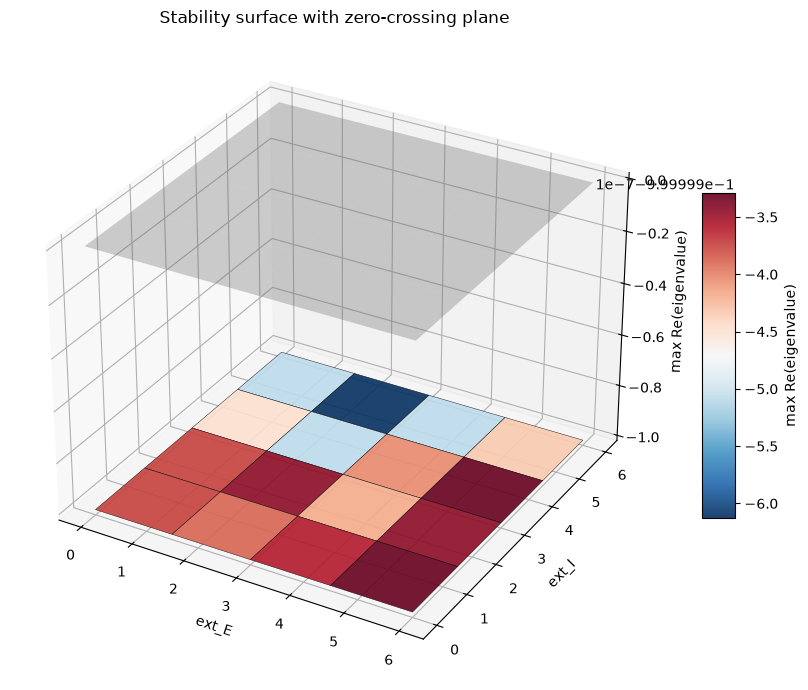

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
print(wExt_sweep_tracker)
max_real_parts, max_complex_coeffs = zip(*wExt_sweep_tracker) 
real_grid = jnp.array(max_real_parts).reshape(len(extI_range), len(extE_range))
imag_grid = jnp.array(max_complex_coeffs).reshape(len(extI_range), len(extE_range))
extE_grid, extI_grid = np.meshgrid(extE_range, extI_range)   # shape matches real_grid: (len(extI_range), len(extE_range))
real_grid_np = np.array(real_grid)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(extE_grid, extI_grid, real_grid_np, cmap='RdBu_r', edgecolor='k', linewidth=0.3, alpha=0.9)

zero_plane = np.zeros_like(real_grid_np)
ax.plot_surface(extE_grid, extI_grid, zero_plane, color='gray', alpha=0.3)

ax.set_xlabel('ext_E')
ax.set_ylabel('ext_I')
ax.set_zlabel('max Re(eigenvalue)')
ax.set_title('Stability surface with zero-crossing plane')
fig.colorbar(surf, shrink=0.5, aspect=10, label='max Re(eigenvalue)')
plt.tight_layout()
plt.show()